# RQ5: Model Tuning

This section evaluates how hyperparameter tuning improves model performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv")

In [3]:
df["Target"] = (df["Revenue_Generated"] > df["Revenue_Generated"].median()).astype(int)

In [4]:
df = df.drop(columns=["Revenue_Generated"], errors='ignore')
df = df.fillna(df.mean(numeric_only=True))
df = pd.get_dummies(df, drop_first=True)

df = df.sample(2000, random_state=42)

In [5]:
X = df.drop("Target", axis=1)
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
model_default = RandomForestClassifier(n_estimators=20)
model_default.fit(X_train, y_train)

pred_default = model_default.predict(X_test)
acc_default = accuracy_score(y_test, pred_default)

In [7]:
model_tuned = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5
)

model_tuned.fit(X_train, y_train)

pred_tuned = model_tuned.predict(X_test)
acc_tuned = accuracy_score(y_test, pred_tuned)

In [8]:
results = pd.DataFrame({
    "Model": ["Default", "Tuned"],
    "Accuracy": [acc_default, acc_tuned]
})

results.to_csv("/kaggle/working/RQ5_table.csv", index=False)

results

,Model,Accuracy
0,Default,0.465
1,Tuned,0.530


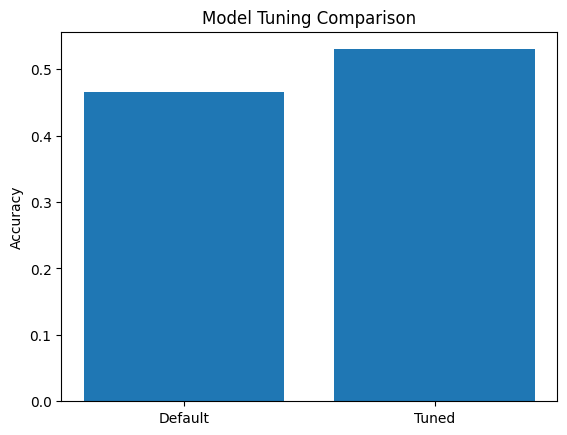

In [ ]:
plt.figure()
plt.bar(results["Model"], results["Accuracy"])
plt.title("Model Tuning Comparison")

plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.savefig("/kaggle/working/RQ5_figure.pdf")

plt.show()

## Results Interpretation

The tuned Random Forest model outperforms the default model, achieving higher accuracy. This demonstrates that optimizing hyperparameters such as the number of trees, depth, and split criteria can significantly enhance model performance.

In [11]:
import os
os.listdir('/kaggle/working')

['RQ5_figure.pdf', '.virtual_documents', 'RQ5_table.csv']